In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load the first dataset (Landsat 8/9)
file_name = 'Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv'

try:
    df = pd.read_csv(file_name)
except FileNotFoundError:
    print(f"Error: Could not find '{file_name}'. Please ensure the file path is correct.")


# 2. Define the Target Variable and clean missing target rows
target_col = 'Target Variable(Chlorophyll-a)'
df = df.dropna(subset=[target_col])

# 3. Define all individual feature columns explicitly
mean_cols = ['mean_SR_B2', 'mean_SR_B3', 'mean_SR_B4', 'mean_SR_B5', 'mean_SR_B6', 'mean_SR_B7']
med_cols  = ['med_SR_B2', 'med_SR_B3', 'med_SR_B4', 'med_SR_B5', 'med_SR_B6', 'med_SR_B7']
sd_cols   = ['sd_SR_B2', 'sd_SR_B3', 'sd_SR_B4', 'sd_SR_B5', 'sd_SR_B6', 'sd_SR_B7']

all_individual_features = mean_cols + med_cols + sd_cols

print(f"Total rows available: {len(df)}")
print(f"Evaluating {len(all_individual_features)} individual features...\n")

results = []

# 4. Loop through EACH column individually
for feature in all_individual_features:
    # Drop rows where THIS specific feature might have a NaN
    temp_df = df[[feature, target_col]].dropna()

    X = temp_df[[feature]]
    y = temp_df[target_col]

    # Split data (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train the model based ONLY on this one feature
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Predict and evaluate
    predictions = rf_model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    # Store the exact values
    results.append({
        'Feature_Name': feature,
        'Group_Type': feature.split('_')[0].upper(), # Extracts 'MEAN', 'MED', or 'SD'
        'R2_Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

# 5. Convert to DataFrame and display sorted by best R2 score
results_df = pd.DataFrame(results)

print("=== INDIVIDUAL FEATURE PERFORMANCE (Ranked by Best to Worst R2) ===")
# Displaying all rows so you can see every single value
display(results_df.sort_values(by='R2_Score', ascending=False).reset_index(drop=True))

Total rows available: 148
Evaluating 18 individual features...

=== INDIVIDUAL FEATURE PERFORMANCE (Ranked by Best to Worst R2) ===


,Feature_Name,Group_Type,R2_Score,RMSE,MAE
0,sd_SR_B5,SD,-0.082929,6.261445,4.573624
1,med_SR_B4,MED,-0.321873,6.792712,4.889008
2,mean_SR_B4,MEAN,-0.349905,6.864358,4.652464
3,med_SR_B6,MED,-0.362351,6.895928,5.250567
4,med_SR_B2,MED,-0.367573,6.909133,4.829252
5,med_SR_B5,MED,-0.406222,7.006081,5.293387
6,sd_SR_B3,SD,-0.436120,7.210574,5.399110
7,mean_SR_B5,MEAN,-0.458128,7.134213,4.369420
8,sd_SR_B7,SD,-0.530019,7.442572,5.408254
9,sd_SR_B6,SD,-0.550978,7.493374,5.459028


Training on 148 rows with 18 total features.

=== COMBINED MODEL RESULTS ===
R-Squared (R2): 0.3933
RMSE: 4.6019


/var/folders/xg/slbv315n7nsgjg7ncb501lxc0000gn/T/ipykernel_2074/3729438498.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')


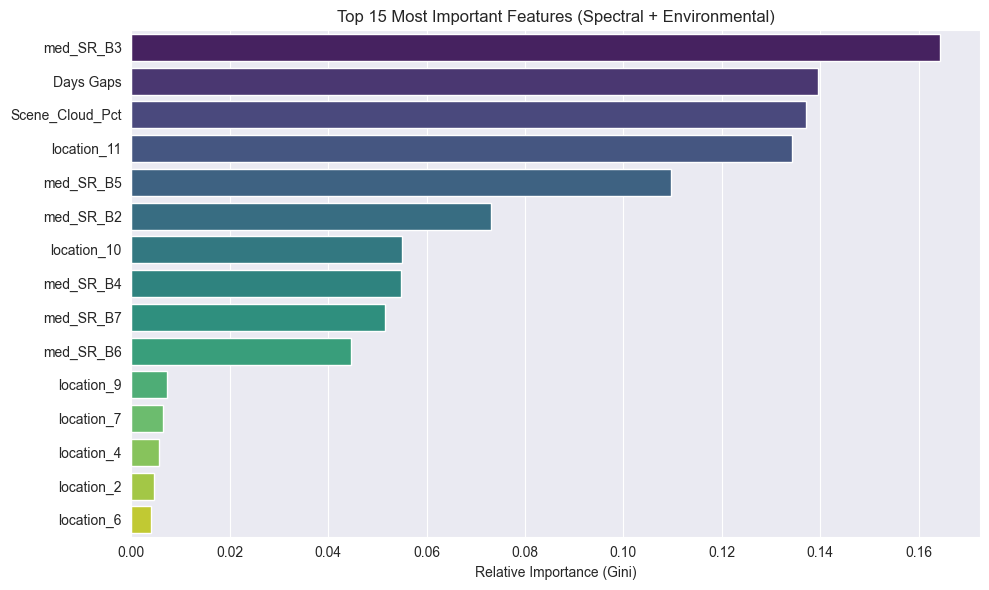

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
# Update the filename to match whichever file you are currently working on (L89 or S2)
file_name = 'Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv'
df = pd.read_csv(file_name)

# Drop missing targets
target_col = 'Target Variable(Chlorophyll-a)'
df = df.dropna(subset=[target_col])

# 2. Define our feature groups
# A. The best spectral bands from our previous tests
spectral_features = ['med_SR_B2', 'med_SR_B3', 'med_SR_B4', 'med_SR_B5', 'med_SR_B6', 'med_SR_B7']
# (If using Sentinel-2, change these to 'med_B2', etc.)

# B. The environmental metadata
# We check if these exist in the dataset first to prevent errors
env_features = []
if 'Days Gaps' in df.columns: env_features.append('Days Gaps')
if 'Scene_Cloud_Pct' in df.columns: env_features.append('Scene_Cloud_Pct')

# 3. Handle Categorical Data (Location)
# Convert location to a string so pandas knows it's a category, not a continuous number
df['location'] = df['location'].astype(str)

# One-Hot Encode the location (Turns 'location_1', 'location_2' into boolean 0/1 columns)
# We drop the first one to avoid the dummy variable trap
df_encoded = pd.get_dummies(df, columns=['location'], drop_first=True)

# Find all the newly created location columns
location_cols = [col for col in df_encoded.columns if 'location_' in col]

# 4. Combine ALL features
all_features = spectral_features + env_features + location_cols

# Ensure we don't have NaNs in our final feature set
final_df = df_encoded[all_features + [target_col]].dropna()

X = final_df[all_features]
y = final_df[target_col]

print(f"Training on {len(final_df)} rows with {len(all_features)} total features.")

# 5. Train the Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# We increase n_estimators a bit because we have more features now
rf_combo = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_combo.fit(X_train, y_train)

# 6. Evaluate
predictions = rf_combo.predict(X_test)
r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("\n=== COMBINED MODEL RESULTS ===")
print(f"R-Squared (R2): {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# 7. Visualize Feature Importance
importances = rf_combo.feature_importances_
indices = np.argsort(importances)[::-1]

# Take only the top 15 features to keep the chart readable
top_n = 15
sorted_features = [all_features[i] for i in indices][:top_n]
sorted_importances = importances[indices][:top_n]

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')
plt.title('Top 15 Most Important Features (Spectral + Environmental)')
plt.xlabel('Relative Importance (Gini)')
plt.tight_layout()
plt.show()

Data successfully aggregated. The dataset has been reduced to 11 rows (one per location).

=== SPATIAL AGGREGATION MODEL RESULTS ===
Leave-One-Out R-Squared (R2): -0.1833
Leave-One-Out RMSE: 2.7941


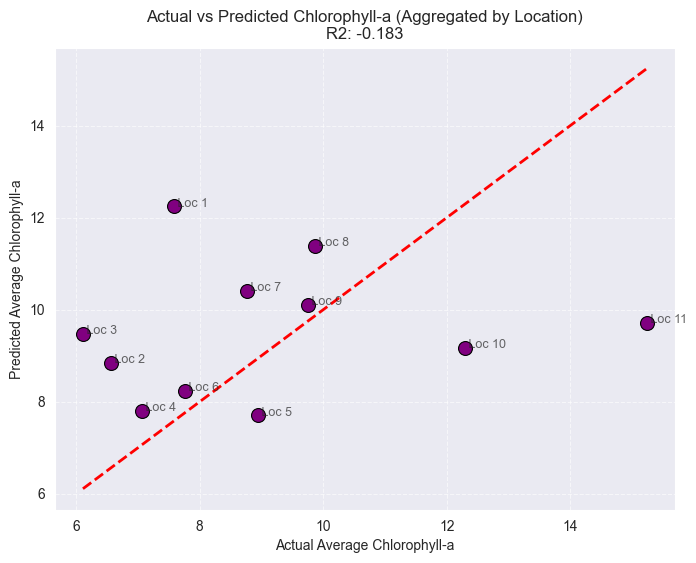

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

# 1. Load the dataset (Using Landsat 8/9 names as the example)
file_name = 'Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv'
df = pd.read_csv(file_name)

# 2. Clean missing targets
target_col = 'Target Variable(Chlorophyll-a)'
df = df.dropna(subset=[target_col])

# 3. Define the spectral bands we want to use
spectral_features = ['med_SR_B2', 'med_SR_B3', 'med_SR_B4', 'med_SR_B5', 'med_SR_B6', 'med_SR_B7']

# 4. COMBINE THE GROUPS BY LOCATION
# We take the numerical columns we care about, group them by location, and calculate the mean
columns_to_keep = spectral_features + [target_col, 'location']
df_grouped = df[columns_to_keep].groupby('location').mean().reset_index()

print(f"Data successfully aggregated. The dataset has been reduced to {len(df_grouped)} rows (one per location).\n")

# 5. Set up the features and target
X = df_grouped[spectral_features]
y = df_grouped[target_col]

# 6. Apply Leave-One-Out Cross Validation
loo = LeaveOneOut()
y_true = []
y_pred = []

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Loop through the data, leaving one location out for testing each time
for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train and predict
    rf_model.fit(X_train, y_train)
    prediction = rf_model.predict(X_test)

    # Store the actual and predicted values
    y_true.append(y_test.values[0])
    y_pred.append(prediction[0])

# 7. Calculate final metrics across all the left-out predictions
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("=== SPATIAL AGGREGATION MODEL RESULTS ===")
print(f"Leave-One-Out R-Squared (R2): {r2:.4f}")
print(f"Leave-One-Out RMSE: {rmse:.4f}")

# 8. Visualizing the Aggregated Predictions
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_true, y=y_pred, color='purple', s=100, edgecolor='k')

# Draw the line of perfect prediction
min_val = min(min(y_true), min(y_pred))
max_val = max(max(y_true), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# Add Location Labels to the dots
for i, txt in enumerate(df_grouped['location']):
    plt.annotate(f" Loc {txt}", (y_true[i], y_pred[i]), fontsize=9, alpha=0.7)

plt.title(f'Actual vs Predicted Chlorophyll-a (Aggregated by Location)\nR2: {r2:.3f}')
plt.xlabel('Actual Average Chlorophyll-a')
plt.ylabel('Predicted Average Chlorophyll-a')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Dataset ready: 148 rows, 8 features.

Calculating Relationship (Correlation) for each feature...
           Feature  Correlation
0        med_SR_B5     0.049833
1  Scene_Cloud_Pct    -0.095085
2        med_SR_B6    -0.129160
3        med_SR_B7    -0.151816
4        med_SR_B4    -0.180065
5        med_SR_B2    -0.198519
6        Days Gaps    -0.241929
7        med_SR_B3    -0.299472

=== TUNED MODEL RESULTS ===
R-Squared (R2): 0.5030


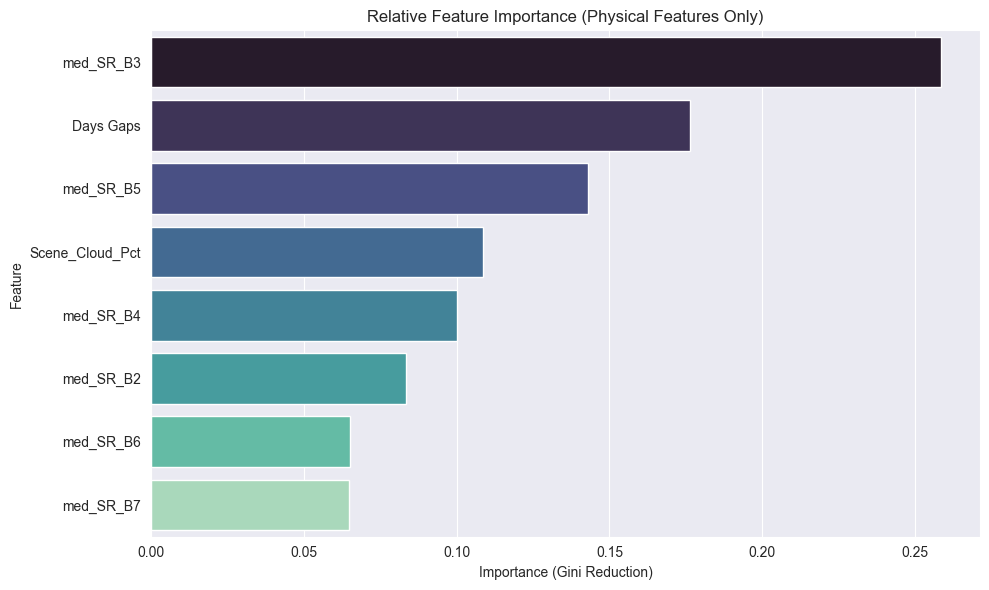

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
file_name = 'Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv'
df = pd.read_csv(file_name)

target_col = 'Target Variable(Chlorophyll-a)'
df = df.dropna(subset=[target_col])

# 2. Define features (Focusing on spectral and environmental data)
spectral_features = ['med_SR_B2', 'med_SR_B3', 'med_SR_B4', 'med_SR_B5', 'med_SR_B6', 'med_SR_B7']
env_features = ['Days Gaps', 'Scene_Cloud_Pct']
all_features = spectral_features + env_features

# Filter data to only include numeric rows
final_df = df[all_features + [target_col]].dropna()

print(f"Dataset ready: {len(final_df)} rows, {len(all_features)} features.\n")

# ==========================================
# PART A: INDIVIDUAL R2 SCORE (Using Correlation for better insight)
# ==========================================
print("Calculating Relationship (Correlation) for each feature...")
corrs = final_df.corr()[target_col].drop(target_col).sort_values(ascending=False)
r2_df = pd.DataFrame({'Feature': corrs.index, 'Correlation': corrs.values})
print(r2_df)

# ==========================================
# PART B: THE OPTIMIZED COMBINED MODEL
# ==========================================
X = final_df[all_features]
y = final_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [2, 4]
}

rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
predictions = best_rf.predict(X_test)

print("\n=== TUNED MODEL RESULTS ===")
print(f"R-Squared (R2): {r2_score(y_test, predictions):.4f}")

# ==========================================
# PART C: VISUALIZE FEATURE IMPORTANCES (FIXED)
# ==========================================
importances = best_rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
# FIXED: Passing the dataframe to 'data' and specifying columns
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='mako', hue='Feature', legend=False)
plt.title('Relative Feature Importance (Physical Features Only)')
plt.xlabel('Importance (Gini Reduction)')
plt.tight_layout()
plt.show()

--- Model Evaluation ---
R-squared Score: 0.2201
RMSE: 5.3135



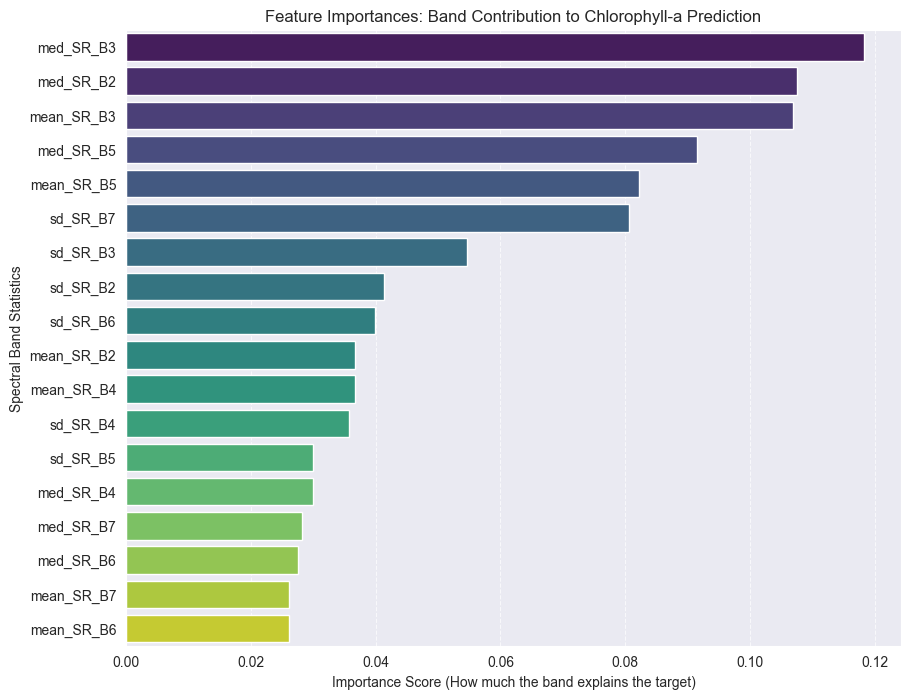

--- Feature Importance Ranking ---
       Feature  Importance
7    med_SR_B3    0.118224
6    med_SR_B2    0.107526
1   mean_SR_B3    0.106907
9    med_SR_B5    0.091522
3   mean_SR_B5    0.082244
17    sd_SR_B7    0.080535
13    sd_SR_B3    0.054710
12    sd_SR_B2    0.041364
16    sd_SR_B6    0.039887
0   mean_SR_B2    0.036771
2   mean_SR_B4    0.036760
14    sd_SR_B4    0.035719
15    sd_SR_B5    0.030042
8    med_SR_B4    0.029890
11   med_SR_B7    0.028128
10   med_SR_B6    0.027525
5   mean_SR_B7    0.026189
4   mean_SR_B6    0.026056


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
df = pd.read_csv('Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv')

# 2. Define target and feature columns
target_col = 'Target Variable(Chlorophyll-a)'
# Selecting columns from 'mean_SR_B2' (index 11) to 'sd_SR_B7' (index 28)
feature_cols = df.columns[11:29].tolist()

# 3. Data Cleaning: Remove rows with missing values in these columns
data = df[[target_col] + feature_cols].dropna()

X = data[feature_cols]
y = data[target_col]

# 4. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and train the Random Forest Regressor
# n_estimators=100 creates 100 decision trees
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 6. Make Predictions and Evaluate
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Evaluation ---")
print(f"R-squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}\n")

# 7. Extract and Visualize Feature Importances
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis',hue = 'Feature', legend=False)
plt.title('Feature Importances: Band Contribution to Chlorophyll-a Prediction')
plt.xlabel('Importance Score (How much the band explains the target)')
plt.ylabel('Spectral Band Statistics')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Display the importance values
print("--- Feature Importance Ranking ---")
print(feature_importance_df)

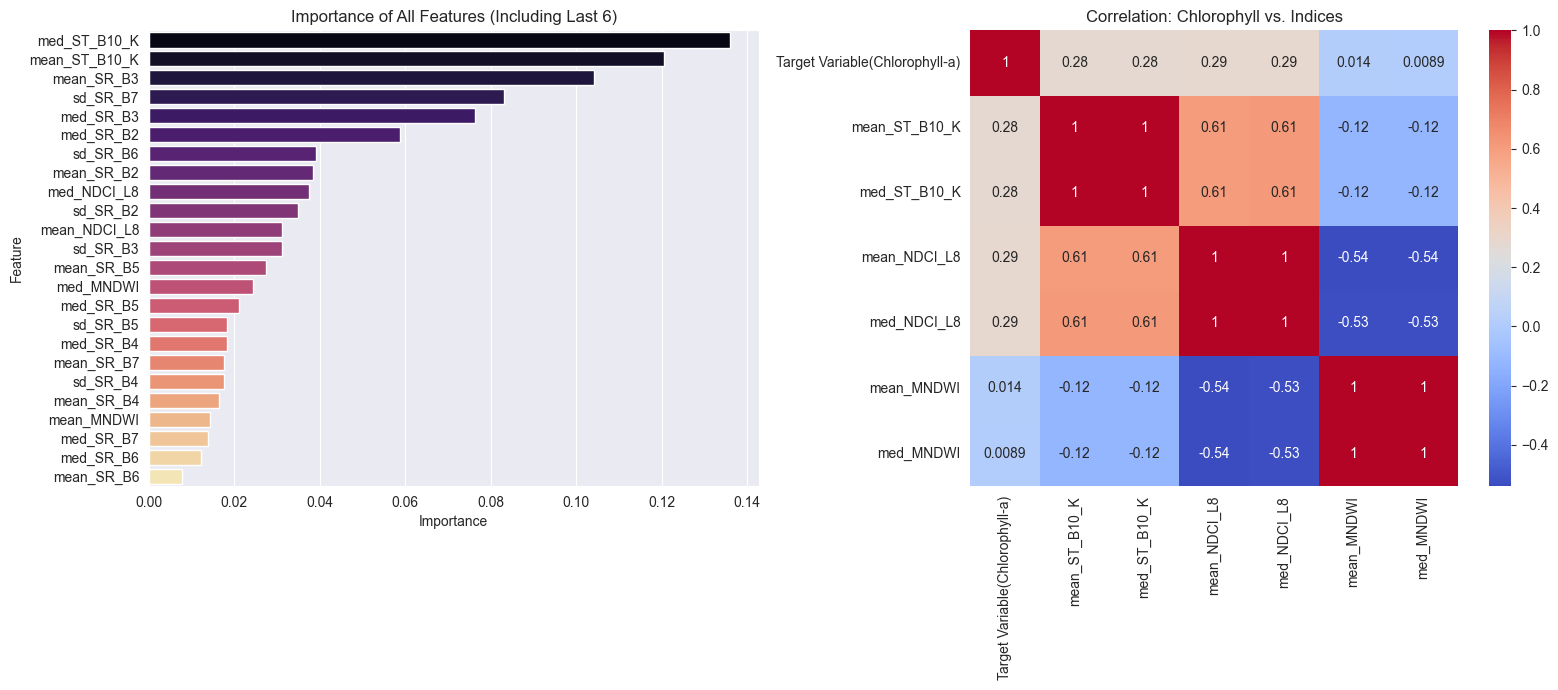

--- Comparison Results ---
Top 5 Influential Features:
          Feature  Importance
19   med_ST_B10_K    0.135913
18  mean_ST_B10_K    0.120473
1      mean_SR_B3    0.104113
17       sd_SR_B7    0.083192
7       med_SR_B3    0.076212

Direct Correlations with Chlorophyll-a:
Target Variable(Chlorophyll-a)    1.000000
mean_NDCI_L8                      0.289216
med_NDCI_L8                       0.285400
mean_ST_B10_K                     0.283422
med_ST_B10_K                      0.282539
mean_MNDWI                        0.014348
med_MNDWI                         0.008882
Name: Target Variable(Chlorophyll-a), dtype: float64


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Load data
df = pd.read_csv('Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv')

# 2. Define Feature Groups
target = 'Target Variable(Chlorophyll-a)'
spectral_bands = df.columns[11:29].tolist()
last_6_indices = df.columns[-6:].tolist() # Thermal, NDCI, MNDWI
all_features = spectral_bands + last_6_indices

# 3. Clean and Split
data = df[[target] + all_features].dropna()
X = data[all_features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the "Full Model"
rf_full = RandomForestRegressor(n_estimators=100, random_state=42)
rf_full.fit(X_train, y_train)

# 5. Compare Feature Importance
importances = rf_full.feature_importances_
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 6. Calculate Correlations for the last 6 columns specifically
correlations = data[[target] + last_6_indices].corr()[target].sort_values(ascending=False)

# --- Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Full Feature Importance
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma', ax=ax[0], hue = 'Feature', legend=False)
ax[0].set_title('Importance of All Features (Including Last 6)')

# Plot 2: Correlation Heatmap for Last 6
sns.heatmap(data[[target] + last_6_indices].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation: Chlorophyll vs. Indices')

plt.tight_layout()
plt.show()

print("--- Comparison Results ---")
print(f"Top 5 Influential Features:\n{importance_df.head(5)}")
print(f"\nDirect Correlations with Chlorophyll-a:\n{correlations}")

Model R-squared: 0.4543
Model RMSE: 4.4449


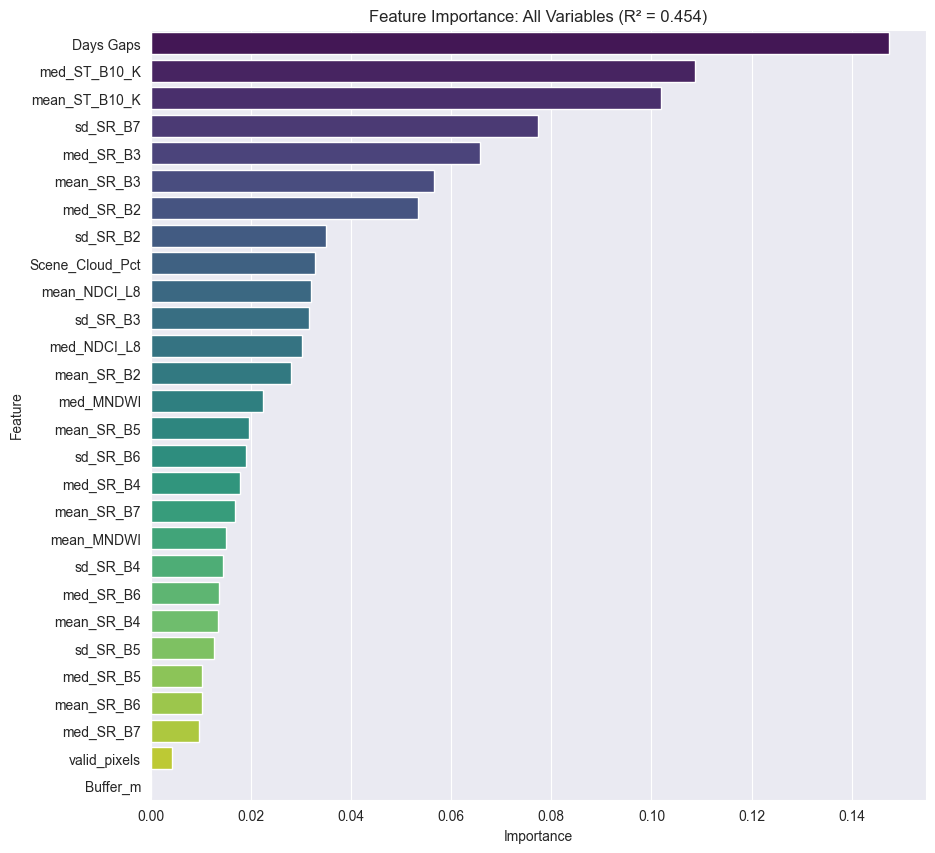

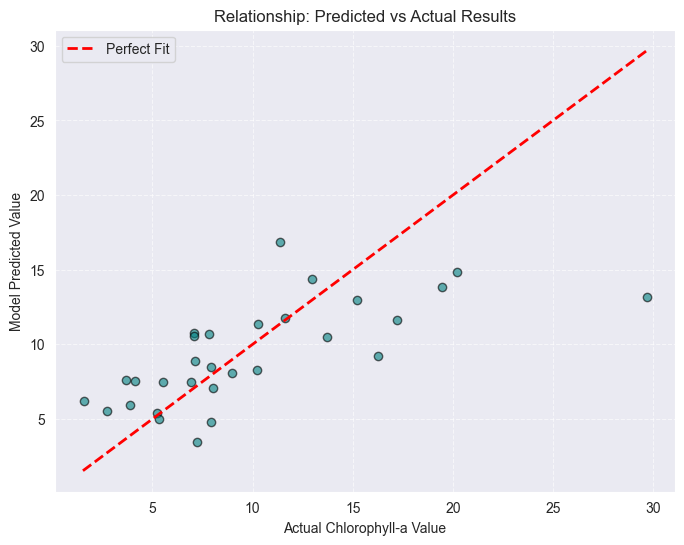

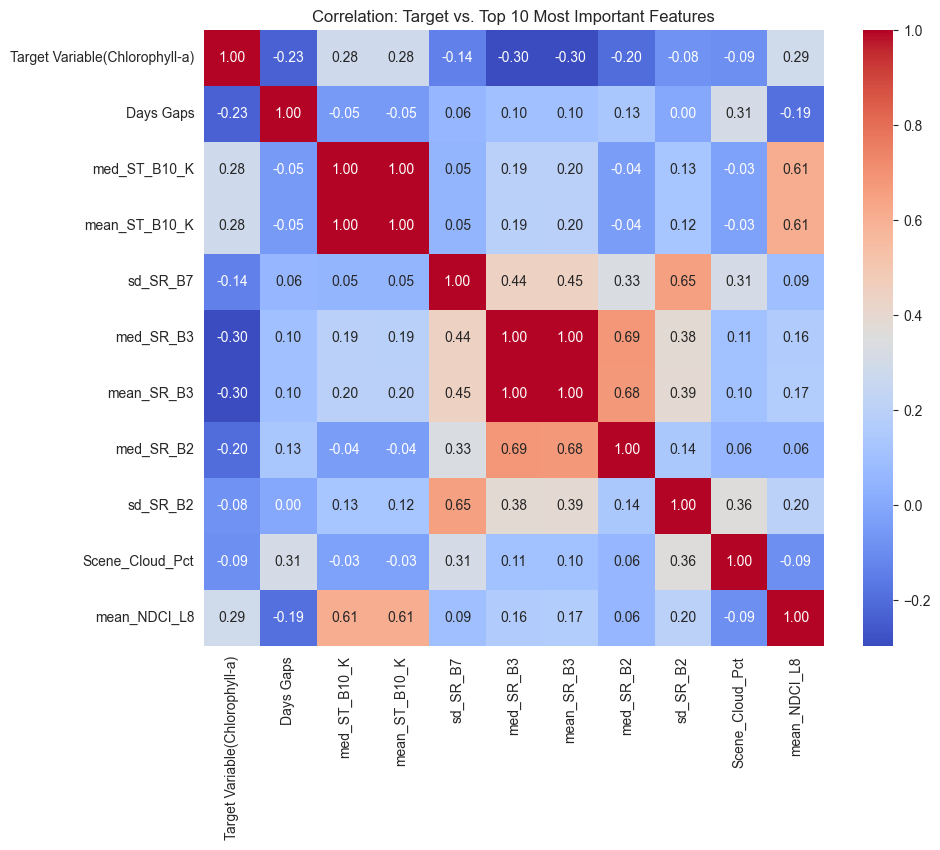

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load the dataset
df = pd.read_csv('Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv')

# 2. Select Features & Target
target_col = 'Target Variable(Chlorophyll-a)'
# We include all numeric features, excluding 'location' as it is an ID
numeric_cols = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_cols if col != target_col and col != 'location']

# 3. Clean Data
data = df[[target_col] + features].dropna()
X = data[features]
y = data[target_col]

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Build the Final Model
# Increasing n_estimators for better stability
rf_final = RandomForestRegressor(n_estimators=200, random_state=42)
rf_final.fit(X_train, y_train)

# 6. Evaluation Metrics
y_pred = rf_final.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model R-squared: {r2:.4f}")
print(f"Model RMSE: {rmse:.4f}")

# --- Visualizations ---

# A. Feature Importance
importances = rf_final.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue = 'Feature', legend=False)
plt.title(f'Feature Importance: All Variables (R² = {r2:.3f})')
plt.show()

# B. Relationship: Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Chlorophyll-a Value')
plt.ylabel('Model Predicted Value')
plt.title('Relationship: Predicted vs Actual Results')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# C. Top 10 Correlation Heatmap
top_features = importance_df.head(10)['Feature'].tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(data[[target_col] + top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Target vs. Top 10 Most Important Features')
plt.show()

--- Spectral Band Model ---
R2 Score: 0.1944
RMSE: 5.4004


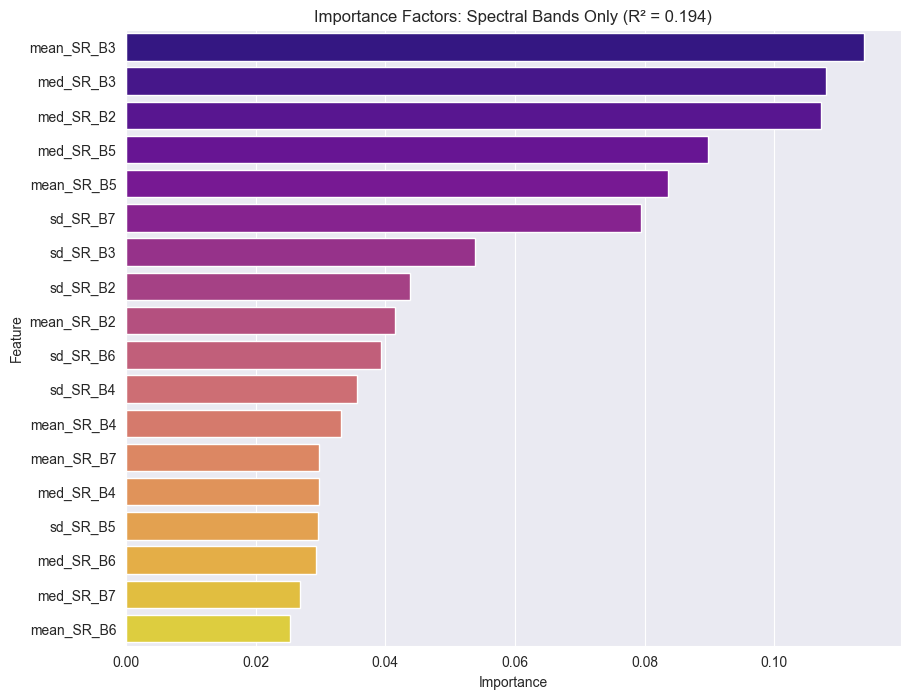

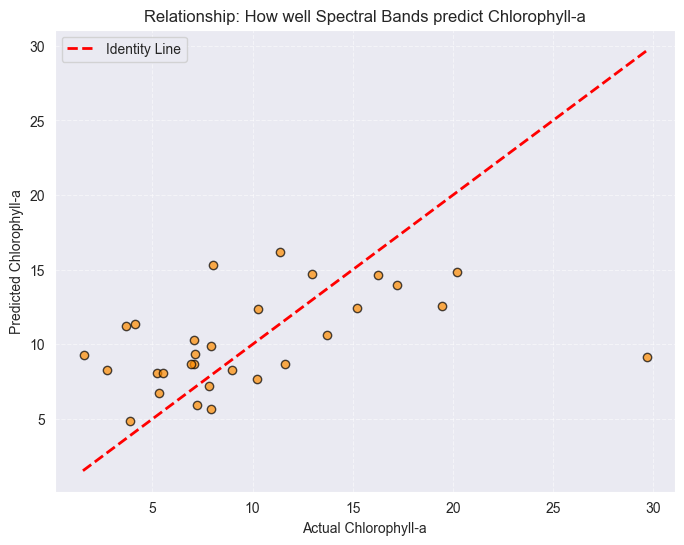

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load data
df = pd.read_csv('Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv')

# 2. Select Features (mean_SR_B2 to sd_SR_B7) and Target
target_col = 'Target Variable(Chlorophyll-a)'
# Selecting columns by name range
feature_cols = df.columns[11:29].tolist()

# 3. Data Preparation
data = df[[target_col] + feature_cols].dropna()
X = data[feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Random Forest
rf_spectral = RandomForestRegressor(n_estimators=200, random_state=42)
rf_spectral.fit(X_train, y_train)

# 5. Metrics
y_pred = rf_spectral.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Spectral Band Model ---")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# 6. Visualizing Importance Factors
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_spectral.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='plasma', hue = 'Feature', legend=False)
plt.title(f'Importance Factors: Spectral Bands Only (R² = {r2:.3f})')
plt.show()

# 7. Visualizing the Relationship (Actual vs Predicted)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='darkorange', edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Identity Line')
plt.xlabel('Actual Chlorophyll-a')
plt.ylabel('Predicted Chlorophyll-a')
plt.title('Relationship: How well Spectral Bands predict Chlorophyll-a')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

/var/folders/xg/slbv315n7nsgjg7ncb501lxc0000gn/T/ipykernel_1297/1897695346.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=r2_df, x='R2 Score', y='Model Type', palette='coolwarm')


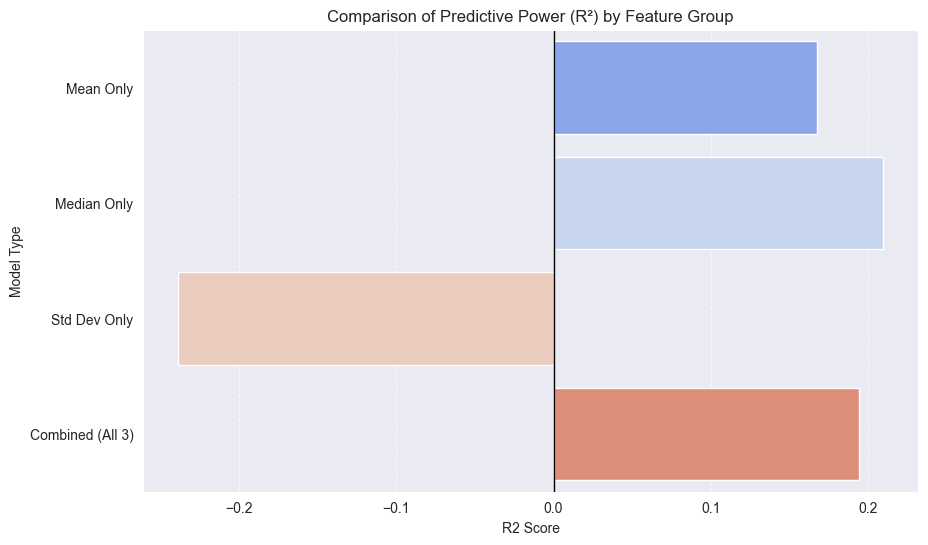

--- Detailed R2 Scores ---
         Model Type  R2 Score
0         Mean Only  0.167696
1       Median Only  0.209603
2      Std Dev Only -0.238879
3  Combined (All 3)  0.194421


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Load data
df = pd.read_csv('Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv')
target_col = 'Target Variable(Chlorophyll-a)'

# 2. Define feature groups
mean_features = ['mean_SR_B2', 'mean_SR_B3', 'mean_SR_B4', 'mean_SR_B5', 'mean_SR_B6', 'mean_SR_B7']
med_features = ['med_SR_B2', 'med_SR_B3', 'med_SR_B4', 'med_SR_B5', 'med_SR_B6', 'med_SR_B7']
sd_features = ['sd_SR_B2', 'sd_SR_B3', 'sd_SR_B4', 'sd_SR_B5', 'sd_SR_B6', 'sd_SR_B7']
combined_features = mean_features + med_features + sd_features

def train_and_score(features, label):
    # Drop NaNs for the specific subset
    subset = df[[target_col] + features].dropna()
    X = subset[features]
    y = subset[target_col]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Model
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    # Return R2 score
    preds = model.predict(X_test)
    return r2_score(y_test, preds)

# 3. Execute Evaluations
results = {
    'Model Type': ['Mean Only', 'Median Only', 'Std Dev Only', 'Combined (All 3)'],
    'R2 Score': [
        train_and_score(mean_features, "Mean"),
        train_and_score(med_features, "Median"),
        train_and_score(sd_features, "SD"),
        train_and_score(combined_features, "Combined")
    ]
}

r2_df = pd.DataFrame(results)

# 4. Visualize Comparisons
plt.figure(figsize=(10, 6))
sns.barplot(data=r2_df, x='R2 Score', y='Model Type', palette='coolwarm')
plt.title('Comparison of Predictive Power (R²) by Feature Group')
plt.axvline(0, color='black', lw=1) # Reference line for zero
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("--- Detailed R2 Scores ---")
print(r2_df)